# Multi-energy FreeTensor slab fit on real ZnPc XRR

Refinement of the legacy free-tensor GlobalObjective (`free_en_offset_init_2`) in refloxide. Companion to `real_data_fit.ipynb`, `free_tensor_model_comparison_repl.py`, and fig. 2 in refl-analysis.

Loads all energies from `reflectivity_data.parquet` (sibling `refl-analysis` checkout). Each energy is a legacy pyref s/p concat (split where `Q` resets); first chunk remaps to native `pol="p"`, second to native `pol="s"`.

**Stack:** vacuum / Surface / ZnPc / Contamination / SiO2 / Si. Film layers are `FreeTensorSLD` with one independent $(\delta_o, \beta_o, \delta_e, \beta_e)$ per measured energy. Oxide and substrate are isotropic `MaterialSLD`, seeded from the free fit.

**Refinement contract:** geometry (film thick/rough, oxide thick/rough/density, substrate rough/density) + per-energy instruments + film free-tensor channels ($k = 11 + 84 + 252 = 347$). Tensors stay fixed until the final polish stage so DE remains tractable.

**Workflow**

1. Seed structure + instruments from `free_en_offset_init_2_summary.json`; build the refloxide stack.
2. Apply free-centered bounds on geometry, instruments, and (later) tensor channels.
3. Refinement: L-BFGS-B on instruments, DE on geometry, DE on geometry+instruments, then L-BFGS-B polish on the full free set including tensors.
4. Overlays, tensor traces, model selection vs legacy free fit, save.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
import os
import pickle
import time
from pathlib import Path

os.environ["POLARS_VERBOSE"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from refnx.analysis import CurveFitter, Transform

from refloxide.data import ReflectDataset
from refloxide.model import FreeTensorSLD, MaterialSLD, ReflectModel
from refloxide.objective import Objective, thread_workers


## Paths and free-tensor seeds

Geometry, per-energy film tensors, and instrument corrections come from the free-tensor extraction (`free_en_offset_init_2_summary.json`), the same published model used in fig. 2. Isotropic oxide/substrate use `MaterialSLD`; only Surface / ZnPc / Contamination carry free tensors.


In [2]:
ZNPC_DATA = (
    Path.home() / "projects/refl-analysis/@data/xrr/znpc/reflectivity_data.parquet"
)
FREE_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/free"
FREE_SUMMARY_PATH = FREE_DIR / "free_en_offset_init_2_summary.json"
FREE_DATA_PATH = FREE_DIR / "free_en_offset_init_2_data.parquet"
for path in (ZNPC_DATA, FREE_SUMMARY_PATH, FREE_DATA_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"missing {path} -- expects sibling refl-analysis checkout and "
            "free_en_offset_init_2 extraction (see free_tensor_model_comparison_repl.py)"
        )

free_summary = json.loads(FREE_SUMMARY_PATH.read_text())
free_frame = pl.read_parquet(FREE_DATA_PATH)
free_layers = {layer["name"]: layer for layer in free_summary["layers"]}
surface_free = free_layers["Surface"]
bulk_free = free_layers["ZnPc"]
interface_free = free_layers["Contamination"]
oxide_free = free_layers["Oxide"]
substrate_free = free_layers["Substrate"]

Q_MIN = 0.0001


def nc_limit(rough: float) -> float:
    return float(np.sqrt(2.0 * np.pi) * rough / 2.0)


def resolve_nc(thick: float, rough: float) -> tuple[float, float]:
    """Project (thick, rough) onto the nearest Nevot-Croce-feasible point."""
    limit = nc_limit(rough)
    if thick >= limit:
        return thick, rough
    thick_proj = limit
    rough_proj = float(2.0 * thick / np.sqrt(2.0 * np.pi))
    if abs(thick_proj - thick) <= abs(rough - rough_proj):
        return thick_proj, rough
    return thick, rough_proj


def seed_window(
    value: float, half_width: float, lo: float, hi: float
) -> tuple[float, float]:
    """Free-fit-centered box clipped to physical ``[lo, hi]``."""
    return (max(lo, value - half_width), min(hi, value + half_width))


SURFACE = {
    "thick": float(surface_free["thick"]),
    "rough": float(surface_free["rough"]),
}
BULK = {
    "thick": float(bulk_free["thick"]),
    "rough": float(bulk_free["rough"]),
}
INTERFACE = {
    "thick": float(interface_free["thick"]),
    "rough": float(interface_free["rough"]),
}
OXIDE = {
    "thick": float(oxide_free["thick"]),
    "rough": float(oxide_free["rough"]),
    "density": float(oxide_free["density"]),
}
SUBSTRATE = {
    "rough": float(substrate_free["rough"]),
    "density": float(substrate_free["density"]),
}

for name, layer in (("SURFACE", SURFACE), ("BULK", BULK), ("INTERFACE", INTERFACE)):
    thick0, rough0 = layer["thick"], layer["rough"]
    layer["thick"], layer["rough"] = resolve_nc(thick0, rough0)
    if (layer["thick"], layer["rough"]) != (thick0, rough0):
        print(
            f"NC snap {name}: thick {thick0:.4f}->{layer['thick']:.4f}, "
            f"rough {rough0:.4f}->{layer['rough']:.4f}"
        )

FREE_INSTRUMENT = {
    float(c["energy"]): (
        float(c["scale_s"]),
        float(c["scale_p"]),
        float(c["theta_offset_p"]),
        float(c["theta_offset_s"]),
        float(c["bkg"]),
        float(c["energy_offset"]),
    )
    for c in free_summary["corrections"]
}

print(f"data:         {ZNPC_DATA}")
print(f"free summary: {FREE_SUMMARY_PATH}")
print(f"free data:    {FREE_DATA_PATH}")
print(
    "film seeds — surface/bulk/interface thick (A): "
    f"{SURFACE['thick']:.4f} / {BULK['thick']:.4f} / {INTERFACE['thick']:.4f}"
)
print(
    "oxide: "
    f"thick={OXIDE['thick']:.4f} A, rough={OXIDE['rough']:.4f} A, "
    f"density={OXIDE['density']:.4f} g/cm^3"
)
print(
    "substrate: "
    f"rough={SUBSTRATE['rough']:.4f} A, "
    f"density={SUBSTRATE['density']:.4f} g/cm^3"
)
print(f"instrument channels: {len(FREE_INSTRUMENT)}")


data:         /Users/hduva/projects/refl-analysis/@data/xrr/znpc/reflectivity_data.parquet
free summary: /Users/hduva/projects/refl-analysis/@models/xrr/znpc/free/free_en_offset_init_2_summary.json
free data:    /Users/hduva/projects/refl-analysis/@models/xrr/znpc/free/free_en_offset_init_2_data.parquet
film seeds — surface/bulk/interface thick (A): 9.9885 / 180.5543 / 11.0031
oxide: thick=8.8372 A, rough=5.0922 A, density=2.2627 g/cm^3
substrate: rough=1.2000 A, density=2.3657 g/cm^3
instrument channels: 21


## Load reflectivity data

All energies from `reflectivity_data.parquet`. Legacy first chunk is native `R_pp` (`pol="p"`); second chunk is native `R_ss` (`pol="s"`).


In [3]:
parts = []
for _, g in pl.read_parquet(ZNPC_DATA).group_by("energy", maintain_order=True):
    q = g["Q"].to_numpy()
    cut = np.flatnonzero(np.diff(q) < 0)
    i = int(cut[0] + 1) if cut.size else len(q)
    pol = np.where(np.arange(len(q)) < i, "p", "s")
    parts.append(g.with_columns(pl.Series("pol", pol)))

frame = (
    pl.concat(parts)
    .rename({"Q": "q", "R": "r", "dR": "r_err"})
    .filter(pl.col("q") >= Q_MIN)
    .select("q", "energy", "pol", "r", "r_err")
)
dataset = ReflectDataset.from_polars(frame)
energies = sorted(frame["energy"].unique().to_list())
print(
    f"ReflectDataset: {len(dataset)} rows, "
    f"{len(list(dataset.groups()))} groups, energies={energies}"
)


ReflectDataset: 2765 rows, 42 groups, energies=[250.0, 275.0, 280.0, 281.0, 281.2, 281.4, 281.6, 281.8, 282.0, 282.3, 282.5, 282.7, 282.9, 283.1, 283.3, 283.5, 283.7, 284.2, 285.1, 287.0, 289.0]


## Measured data overview

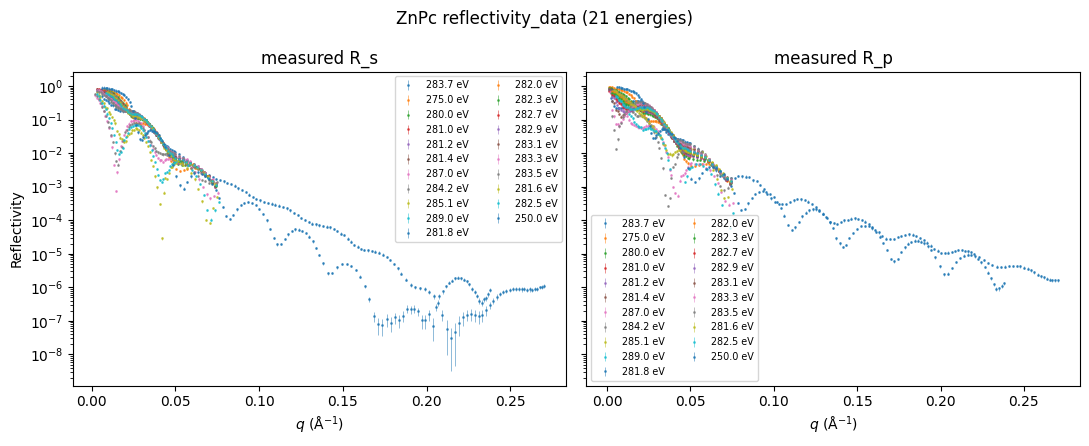

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for energy, pol, indices in dataset.groups():
    ax = axes[0] if pol == "s" else axes[1]
    ax.errorbar(
        dataset.q[indices],
        dataset.r[indices],
        yerr=dataset.r_err[indices],
        fmt=".",
        ms=2,
        lw=0.5,
        alpha=0.7,
        label=f"{energy:.1f} eV",
    )
axes[0].set_title("measured R_s")
axes[1].set_title("measured R_p")
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
    ax.legend(fontsize="x-small", ncol=2)
axes[0].set_ylabel("Reflectivity")
fig.suptitle(f"ZnPc reflectivity_data ({len(energies)} energies)")
fig.tight_layout()
plt.show()


## FreeTensor stack

Surface / ZnPc / Contamination are `FreeTensorSLD` with per-energy channels seeded from the legacy free fit. Vacuum, oxide, and substrate are isotropic `MaterialSLD`.


In [5]:
FILM_LAYER_NAMES = ("Surface", "ZnPc", "Contamination")


def seed_free_tensor_sld(layer: dict, *, name: str) -> FreeTensorSLD:
    sld = FreeTensorSLD(energies, name=name)
    for energy_str, values in layer["tensor_by_energy"].items():
        channel = sld.channel_at(float(energy_str))
        channel.delta_o.value = values["delta_o"]
        channel.beta_o.value = values["beta_o"]
        channel.delta_e.value = values["delta_e"]
        channel.beta_e.value = values["beta_e"]
    return sld


def build_structure():
    vacuum = MaterialSLD("", 0, name="Vacuum")(0, 0)
    surface = seed_free_tensor_sld(surface_free, name="Surface")(
        SURFACE["thick"], SURFACE["rough"]
    )
    bulk = seed_free_tensor_sld(bulk_free, name="ZnPc")(
        BULK["thick"], BULK["rough"]
    )
    interface = seed_free_tensor_sld(interface_free, name="Contamination")(
        INTERFACE["thick"], INTERFACE["rough"]
    )
    oxide = MaterialSLD("SiO2", density=OXIDE["density"], name="Oxide")(
        OXIDE["thick"], OXIDE["rough"]
    )
    substrate = MaterialSLD("Si", density=SUBSTRATE["density"], name="Substrate")(
        0, SUBSTRATE["rough"]
    )
    return vacuum | surface | bulk | interface | oxide | substrate


model = ReflectModel(build_structure(), energies=energies, parallel=False)
structure = model.structure
surface = structure.slab("Surface")
bulk = structure.slab("ZnPc")
interface = structure.slab("Contamination")
oxide = structure.slab("Oxide")
substrate = structure.slab("Substrate")
film_slabs = tuple(structure.slab(name) for name in FILM_LAYER_NAMES)
film_slds = tuple(slab.sld for slab in film_slabs)

assert all(isinstance(sld, FreeTensorSLD) for sld in film_slds)
assert surface.enforce_nevot_croce and bulk.enforce_nevot_croce
assert interface.enforce_nevot_croce and oxide.enforce_nevot_croce
assert not structure.slab("Vacuum").enforce_nevot_croce
assert not substrate.enforce_nevot_croce

print(structure)


## Matched-$k$ refinement bounds

Seeded at the legacy free fit. Geometry and instruments use narrow free-centered windows. Film tensor channels get modest relative boxes around the seeded $\delta$ / $\beta$ values; they stay fixed until the final polish stage.

Expected $k = 347$: $11$ geometry + $84$ instruments + $252$ film tensor channels ($3 \times 21 \times 4$).


In [6]:
def nc_thick_lower(rough_upper: float) -> float:
    return nc_limit(rough_upper)


def snap_into_bounds(
    thick: float,
    rough: float,
    *,
    thick_bounds: tuple[float, float],
    rough_bounds: tuple[float, float],
    frac: float = 1e-9,
) -> tuple[float, float]:
    """Clamp thick/rough into box bounds, then project onto Nevot-Croce."""
    thick_lo, thick_hi = thick_bounds
    rough_lo, rough_hi = rough_bounds
    thick_span = thick_hi - thick_lo
    rough_span = rough_hi - rough_lo
    thick_lo_i = thick_lo + frac * thick_span
    thick_hi_i = thick_hi - frac * thick_span
    rough_lo_i = rough_lo + frac * rough_span
    rough_hi_i = rough_hi - frac * rough_span
    thick_c = float(np.clip(thick, thick_lo_i, thick_hi_i))
    rough_c = float(np.clip(rough, rough_lo_i, rough_hi_i))
    thick_r, rough_r = resolve_nc(thick_c, rough_c)
    thick_r = float(np.clip(thick_r, thick_lo_i, thick_hi_i))
    rough_r = float(np.clip(rough_r, rough_lo_i, rough_hi_i))
    thick_r, rough_r = resolve_nc(thick_r, rough_r)
    if thick_r < thick_lo_i or thick_r > thick_hi_i:
        thick_r = thick_lo_i
        rough_r = min(rough_r, 2.0 * thick_r / np.sqrt(2.0 * np.pi))
        rough_r = float(np.clip(rough_r, rough_lo_i, rough_hi_i))
    return thick_r, rough_r


def tensor_component_bounds(
    value: float, *, rel: float = 0.20, floor: float = 5e-5
) -> tuple[float, float]:
    """Modest relative box around one seeded tensor component."""
    v = float(value)
    span = max(rel * max(abs(v), floor), floor)
    if v >= 0.0:
        lo = max(-0.01, v - span)
        hi = v + span
    else:
        lo = v - span
        hi = min(0.01, v + span)
    if hi <= lo:
        hi = lo + floor
    return lo, hi


SCALE_DELTA = 0.08
SCALE_LO, SCALE_HI = 0.75, 1.45
THETA_DELTA = 0.08

SURFACE_ROUGH_HI = max(SURFACE["rough"] + 2.0, SURFACE["rough"] * 1.15)
INTERFACE_ROUGH_HI = max(INTERFACE["rough"] + 2.0, INTERFACE["rough"] * 1.15)
BULK_ROUGH_HI = max(BULK["rough"] + 2.0, BULK["rough"] * 1.1)

SURFACE_THICK_BOUNDS = seed_window(
    SURFACE["thick"], 4.0, nc_thick_lower(SURFACE_ROUGH_HI), 25.0
)
SURFACE_ROUGH_BOUNDS = seed_window(SURFACE["rough"], 2.5, 0.5, SURFACE_ROUGH_HI)
INTERFACE_THICK_BOUNDS = seed_window(
    INTERFACE["thick"], 4.0, nc_thick_lower(INTERFACE_ROUGH_HI), 25.0
)
INTERFACE_ROUGH_BOUNDS = seed_window(
    INTERFACE["rough"], 2.5, 0.5, INTERFACE_ROUGH_HI
)
BULK_THICK_BOUNDS = seed_window(BULK["thick"], 8.0, 160.0, 200.0)
BULK_ROUGH_BOUNDS = seed_window(BULK["rough"], 2.0, 5.0, BULK_ROUGH_HI)

surface_thick0, surface_rough0 = snap_into_bounds(
    SURFACE["thick"],
    SURFACE["rough"],
    thick_bounds=SURFACE_THICK_BOUNDS,
    rough_bounds=SURFACE_ROUGH_BOUNDS,
)
interface_thick0, interface_rough0 = snap_into_bounds(
    INTERFACE["thick"],
    INTERFACE["rough"],
    thick_bounds=INTERFACE_THICK_BOUNDS,
    rough_bounds=INTERFACE_ROUGH_BOUNDS,
)
bulk_thick0, bulk_rough0 = snap_into_bounds(
    BULK["thick"],
    BULK["rough"],
    thick_bounds=BULK_THICK_BOUNDS,
    rough_bounds=BULK_ROUGH_BOUNDS,
)

for param in model.parameters.flattened():
    param.vary = False

OXIDE_THICK_BOUNDS = seed_window(OXIDE["thick"], 3.0, 2.0, 20.0)
OXIDE_ROUGH_BOUNDS = seed_window(OXIDE["rough"], 2.0, 0.5, 15.0)
oxide.thick.setp(value=OXIDE["thick"], vary=True, bounds=OXIDE_THICK_BOUNDS)
oxide.rough.setp(value=OXIDE["rough"], vary=True, bounds=OXIDE_ROUGH_BOUNDS)
oxide.sld.density.setp(
    value=OXIDE["density"],
    vary=True,
    bounds=seed_window(OXIDE["density"], 0.25, 1.5, 2.4),
)

substrate.rough.setp(
    value=SUBSTRATE["rough"],
    vary=True,
    bounds=seed_window(SUBSTRATE["rough"], 0.4, 0.5, 3.0),
)
substrate.sld.density.setp(
    value=SUBSTRATE["density"],
    vary=True,
    bounds=seed_window(SUBSTRATE["density"], 0.15, 2.0, 2.8),
)

bulk.thick.setp(value=bulk_thick0, vary=True, bounds=BULK_THICK_BOUNDS)
bulk.rough.setp(value=bulk_rough0, vary=True, bounds=BULK_ROUGH_BOUNDS)
surface.thick.setp(value=surface_thick0, vary=True, bounds=SURFACE_THICK_BOUNDS)
surface.rough.setp(value=surface_rough0, vary=True, bounds=SURFACE_ROUGH_BOUNDS)
interface.thick.setp(value=interface_thick0, vary=True, bounds=INTERFACE_THICK_BOUNDS)
interface.rough.setp(value=interface_rough0, vary=True, bounds=INTERFACE_ROUGH_BOUNDS)

for layer_name in FILM_LAYER_NAMES:
    layer = free_layers[layer_name]
    sld = structure.slab(layer_name).sld
    assert isinstance(sld, FreeTensorSLD)
    for energy_str, values in layer["tensor_by_energy"].items():
        channel = sld.channel_at(float(energy_str))
        channel.delta_o.setp(
            value=values["delta_o"],
            vary=True,
            bounds=tensor_component_bounds(values["delta_o"]),
        )
        channel.beta_o.setp(
            value=values["beta_o"],
            vary=True,
            bounds=tensor_component_bounds(values["beta_o"], rel=0.25, floor=1e-5),
        )
        channel.delta_e.setp(
            value=values["delta_e"],
            vary=True,
            bounds=tensor_component_bounds(values["delta_e"]),
        )
        channel.beta_e.setp(
            value=values["beta_e"],
            vary=True,
            bounds=tensor_component_bounds(values["beta_e"], rel=0.25, floor=1e-5),
        )

energy_offsets = {v[5] for v in FREE_INSTRUMENT.values()}
assert len(energy_offsets) == 1
model.energy_offset.setp(value=energy_offsets.pop(), vary=False)

for energy, (sc_s, sc_p, th_s, th_p, bkg, _eoff) in FREE_INSTRUMENT.items():
    model.scale_s.at(energy).setp(
        value=sc_s,
        vary=True,
        bounds=(max(SCALE_LO, sc_s - SCALE_DELTA), min(SCALE_HI, sc_s + SCALE_DELTA)),
    )
    model.scale_p.at(energy).setp(
        value=sc_p,
        vary=True,
        bounds=(max(SCALE_LO, sc_p - SCALE_DELTA), min(SCALE_HI, sc_p + SCALE_DELTA)),
    )
    model.theta_offset_s.at(energy).setp(
        value=th_s,
        vary=True,
        bounds=(th_s - THETA_DELTA, th_s + THETA_DELTA),
    )
    model.theta_offset_p.at(energy).setp(
        value=th_p,
        vary=True,
        bounds=(th_p - THETA_DELTA, th_p + THETA_DELTA),
    )
    model.bkg.at(energy).setp(value=bkg, vary=False)

model.parallel = False
objective = Objective(
    model, dataset, transform=Transform("logY"), nc_constraint=False
)

TARGET_K = 11 + 4 * len(energies) + 4 * len(FILM_LAYER_NAMES) * len(energies)
n_vary = len(objective.varying_parameters())
print(f"nc_constraint={objective.nc_constraint}")
print(f"energies: {len(energies)}, batches: {len(objective._batches)}")
print(f"varying parameters k={n_vary} (target {TARGET_K})")
assert n_vary == TARGET_K, f"expected matched k={TARGET_K}, got {n_vary}"
assert np.isfinite(objective.logp()), "starting point must lie inside box bounds"
print(f"logl at free seed: {float(objective.logl()):.3f}")


nc_constraint=False
energies: 21, batches: 42
varying parameters k=347 (target 347)
logl at free seed: -5937.749


## Refinement fit (all energies)

Four stages from the free-tensor seed:

1. **L-BFGS-B** — instruments only (geometry and tensors frozen)
2. **DE** — geometry only (instruments frozen at stage-1 values)
3. **DE** — geometry + instruments together (tensors still frozen)
4. **L-BFGS-B polish** — full free set including film tensor channels, then attach local-Hessian `stderr`

Rayon stays off; DE uses `thread_workers`.


In [7]:
def set_instrument_vary(active: bool) -> None:
    for energy in energies:
        model.scale_s.at(energy).vary = active
        model.scale_p.at(energy).vary = active
        model.theta_offset_s.at(energy).vary = active
        model.theta_offset_p.at(energy).vary = active


def set_geometry_vary(active: bool, *, final: bool = False) -> None:
    for slab in film_slabs:
        slab.thick.vary = active
        slab.rough.vary = active
    oxide.thick.vary = active
    oxide.rough.vary = active
    oxide.sld.density.vary = final
    substrate.rough.vary = active
    substrate.sld.density.vary = final


def set_tensor_vary(active: bool) -> None:
    for sld in film_slds:
        assert isinstance(sld, FreeTensorSLD)
        for channel in sld._channels.values():
            channel.delta_o.vary = active
            channel.beta_o.vary = active
            channel.delta_e.vary = active
            channel.beta_e.vary = active


def nudge_varying_inside_bounds(objective: Objective, *, frac: float = 1e-9) -> list[float]:
    """Move varying values strictly inside box bounds for SciPy DE ``x0``."""
    x0: list[float] = []
    for param in objective.varying_parameters():
        bounds = param.bounds
        value = float(param.value or 0.0)
        if bounds is None or not hasattr(bounds, "lb"):
            x0.append(value)
            continue
        lo = float(bounds.lb)
        hi = float(bounds.ub)
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            x0.append(value)
            continue
        span = hi - lo
        nudged = float(np.clip(value, lo + frac * span, hi - frac * span))
        if nudged != value:
            param.value = nudged
        x0.append(nudged)
    return x0


def run_lbfgsb(label: str, *, maxiter: int = 500) -> None:
    n_vary = len(objective.varying_parameters())
    print(f"\n{label}: {n_vary} varying parameters")
    print(f"  logl before: {float(objective.logl()):.3f}")
    assert np.isfinite(objective.logp()), f"{label}: start outside bounds"
    nudge_varying_inside_bounds(objective)
    t0 = time.perf_counter()
    res = CurveFitter(objective).fit(
        method="L-BFGS-B",
        options={"maxiter": maxiter},
    )
    print(
        f"  L-BFGS-B maxiter={maxiter}: {time.perf_counter() - t0:.2f} s, "
        f"success={getattr(res, 'success', None)}, "
        f"logl={float(objective.logl()):.3f}"
    )


def attach_stderr_from_covar(objective: Objective) -> int:
    """Write local-Hessian stderr onto every varying Parameter."""
    varying = list(objective.varying_parameters())
    errors = np.sqrt(np.diag(np.asarray(objective.covar(), dtype=float)))
    for param in objective.parameters.flattened():
        param.stderr = None
        param.chain = None
    n_ok = 0
    for param, err in zip(varying, errors, strict=True):
        if np.isfinite(err):
            param.stderr = float(err)
            n_ok += 1
    return n_ok


def run_de(label: str, *, maxiter: int, popsize: int, polish: bool) -> None:
    n_vary = len(objective.varying_parameters())
    print(f"\n{label}: {n_vary} varying parameters")
    print(f"  logl before: {float(objective.logl()):.3f}")
    assert np.isfinite(objective.logp()), f"{label}: start outside bounds"
    x0 = nudge_varying_inside_bounds(objective)
    with thread_workers(12) as workers:
        workers.bind(objective)
        t0 = time.perf_counter()
        CurveFitter(objective).fit(
            method="differential_evolution",
            popsize=popsize,
            maxiter=maxiter,
            polish=polish,
            seed=1,
            workers=workers,
            updating="deferred",
            x0=x0,
        )
        print(
            f"  DE maxiter={maxiter} polish={polish}: "
            f"{time.perf_counter() - t0:.2f} s, "
            f"logl={float(objective.logl()):.3f}"
        )


set_tensor_vary(False)

logl_before = float(objective.logl())
print(f"bulk thick start = {bulk.thick.value:.2f}")
print(f"logl at free seed: {logl_before:.3f}")

set_geometry_vary(False)
set_instrument_vary(True)
run_lbfgsb("stage 1: L-BFGS-B instruments only", maxiter=500)

set_instrument_vary(False)
set_geometry_vary(True)
run_de("stage 2: DE geometry only", maxiter=40, popsize=12, polish=False)

set_instrument_vary(True)
set_geometry_vary(True)
run_de("stage 3: DE geometry + instruments", maxiter=50, popsize=12, polish=False)

set_instrument_vary(True)
set_geometry_vary(True, final=True)
set_tensor_vary(True)
run_lbfgsb("stage 4: L-BFGS-B polish (full free set)", maxiter=2000)
n_err = attach_stderr_from_covar(objective)
print(f"parameters with stderr: {n_err}/{len(objective.varying_parameters())}")

logl_after = float(objective.logl())
recovered = float(bulk.thick.value or 0.0)
print(f"\nrecovered bulk thick = {recovered:.2f} A")
print(f"energy_offset = {model.energy_offset.value:.4f} eV")
print(f"logl after:  {logl_after:.3f}")
print(f"delta logl = {logl_after - logl_before:.3f}")
assert np.isfinite(logl_before) and np.isfinite(logl_after)
print(f"final k = {len(objective.varying_parameters())}")
print(objective)


bulk thick start = 180.55
logl at free seed: -5937.749

stage 1: L-BFGS-B instruments only: 84 varying parameters
  logl before: -5937.749


193.43385727933264: : 29it [00:15,  1.92it/s]


  L-BFGS-B maxiter=500: 16.09 s, success=True, logl=-193.434

stage 2: DE geometry only: 9 varying parameters
  logl before: -193.434


-421.5880913485687: : 40it [00:07,  5.02it/s] 


  DE maxiter=40 polish=False: 7.98 s, logl=421.588

stage 3: DE geometry + instruments: 93 varying parameters
  logl before: 421.588


-421.58808784334724: : 50it [01:47,  2.14s/it]


  DE maxiter=50 polish=False: 107.09 s, logl=421.588

stage 4: L-BFGS-B polish (full free set): 347 varying parameters
  logl before: 421.588


-3072.0070294195575: : 41it [01:36,  2.36s/it]


  L-BFGS-B maxiter=2000: 96.71 s, success=False, logl=3072.007
parameters with stderr: 347/347

recovered bulk thick = 179.09 A
energy_offset = 0.0000 eV
logl after:  3072.007
delta logl = 9009.756
final k = 347
________________________________________________________________________________
Objective - reflectivity_objective
Dataset = <None>, 2765 points
datapoints = 2765
chi2 = 7179.342183727562
Weighted = True
Transform = Transform('logY')
________________________________________________________________________________
Parameters: 'reflect_model'
________________________________________________________________________________
Parameters: 'experiment_corrections'
________________________________________________________________________________
Parameters:    'shared'    
<Parameter:'energy_offset', value=0  (fixed) , bounds=[-1.0, 1.0]>
<Parameter:     'dq'      , value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
________________

## Overlay data vs fit

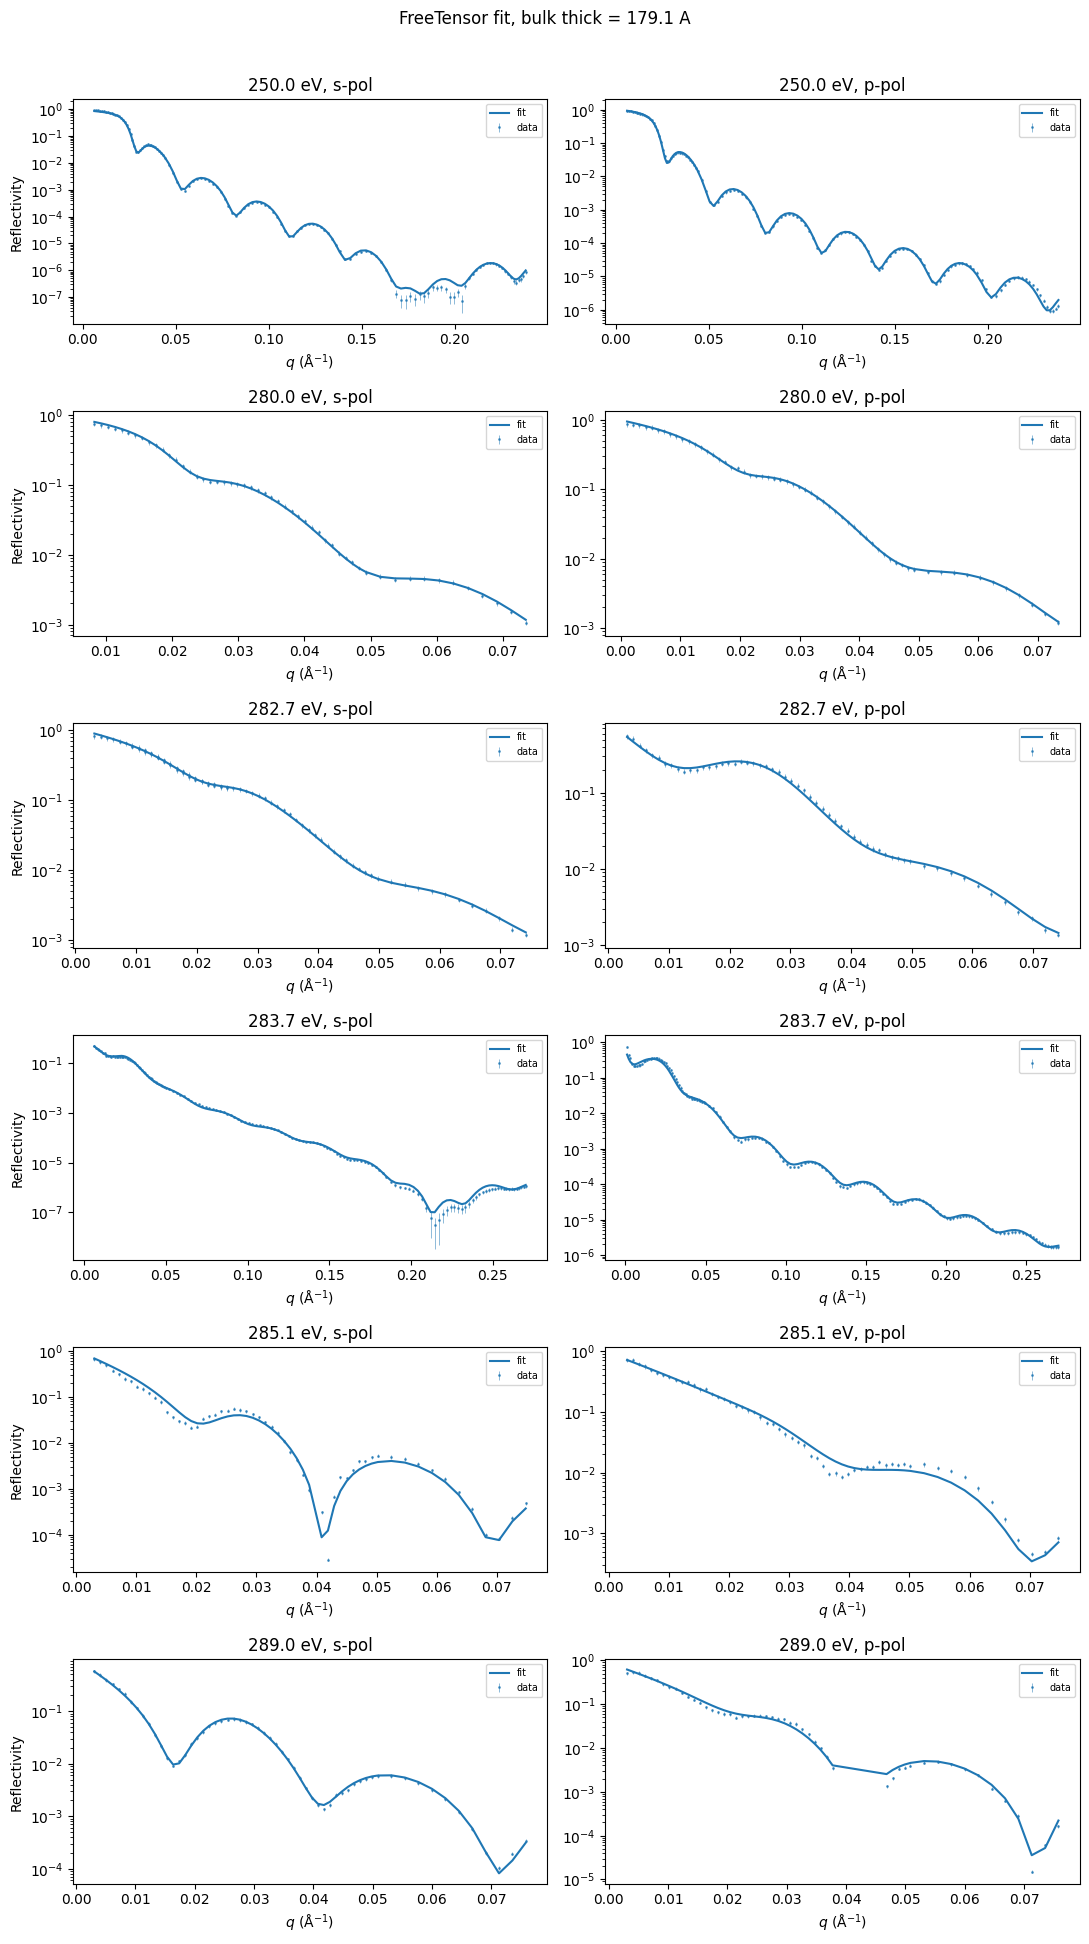

In [8]:
show_energies = (250.0, 280.0, 282.7, 283.7, 285.1, 289.0)
fig, axes = plt.subplots(len(show_energies), 2, figsize=(11, 3.2 * len(show_energies)))
for row, energy in enumerate(show_energies):
    for col, pol in enumerate(("s", "p")):
        ax = axes[row, col]
        for e, p, indices in dataset.groups():
            if e != energy or p != pol:
                continue
            q = dataset.q[indices]
            ax.errorbar(
                q,
                dataset.r[indices],
                yerr=dataset.r_err[indices],
                fmt=".",
                ms=2,
                lw=0.5,
                alpha=0.7,
                label="data",
            )
            result = model(q, energy)
            fit = result.s if pol == "s" else result.p
            ax.plot(
                q,
                fit,
                color="C0",
                lw=1.5,
                label="fit",
            )
        ax.set_yscale("log")
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
        ax.set_title(f"{energy:.1f} eV, {pol}-pol")
        if col == 0:
            ax.set_ylabel("Reflectivity")
        ax.legend(fontsize="x-small")
fig.suptitle(f"FreeTensor fit, bulk thick = {recovered:.1f} A", y=1.01)
fig.tight_layout()
plt.show()


## Free-tensor dispersion after fit

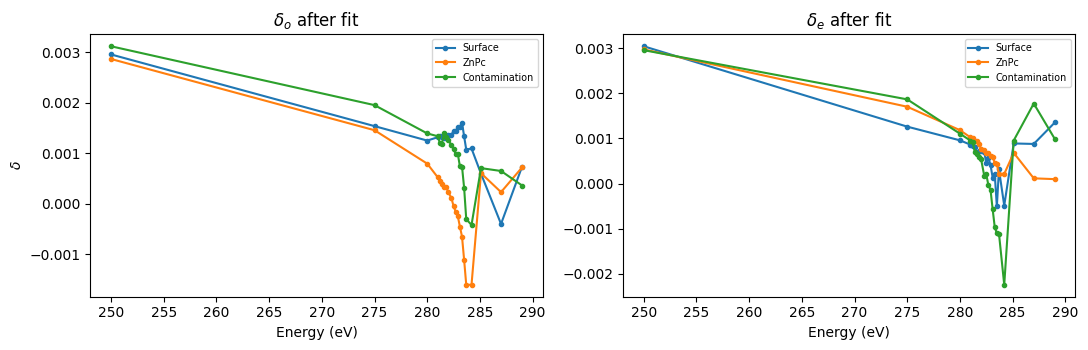

________________________________________________________________________________
Parameters:      None      
<Parameter:'scale_s@250p0eV', value=0.933466 +/- 0.0264, bounds=[0.8991713132760663, 1.0591713132760663]>
<Parameter:'scale_p@250p0eV', value=1.05814 +/- 0.0286, bounds=[0.9613461267185114, 1.1213461267185114]>
<Parameter:'theta_offset_s@250p0eV', value=0.16922 +/- 0.0955, bounds=[0.12259464766721624, 0.28259464766721626]>
<Parameter:'theta_offset_p@250p0eV', value=0.439632 +/- 0.0997, bounds=[0.4068218832048406, 0.5668218832048406]>
<Parameter:'scale_s@275p0eV', value=1.09497 +/- 0.0532, bounds=[0.9349685505435191, 1.0949685505435192]>
<Parameter:'scale_p@275p0eV', value=1.07766 +/- 0.063, bounds=[0.917693906390544, 1.077693906390544]>
<Parameter:'theta_offset_s@275p0eV', value=0.319876 +/- 0.391, bounds=[0.31987580202756954, 0.4798758020275696]>
<Parameter:'theta_offset_p@275p0eV', value=0.467226 +/- 0.461, bounds=[0.467192488206067, 0.627192488206067]>
<Parameter:'scale_s@280

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for layer_name in FILM_LAYER_NAMES:
    sld = structure.slab(layer_name).sld
    assert isinstance(sld, FreeTensorSLD)
    es = sorted(float(e) for e in sld._channels)
    delta_o = [float(sld.channel_at(e).delta_o.value or 0.0) for e in es]
    delta_e = [float(sld.channel_at(e).delta_e.value or 0.0) for e in es]
    axes[0].plot(es, delta_o, marker=".", label=layer_name)
    axes[1].plot(es, delta_e, marker=".", label=layer_name)
axes[0].set_title(r"$\delta_o$ after fit")
axes[1].set_title(r"$\delta_e$ after fit")
for ax in axes:
    ax.set_xlabel("Energy (eV)")
    ax.legend(fontsize="x-small")
axes[0].set_ylabel(r"$\delta$")
fig.tight_layout()
plt.show()

print(objective.varying_parameters())


## Compare against the legacy free-tensor GlobalObjective

Legacy layer names map directly (Surface / ZnPc / Contamination). Film tensors are compared at 283.7 eV; geometry compares thick/rough and oxide/substrate density. Requires the one-time extraction from `free_tensor_model_comparison_repl.py`.


In [10]:
print(f"{'role':<16}{'param':<10}{'ours':>12}{'legacy free':>12}{'delta':>12}")
for layer_name in FILM_LAYER_NAMES:
    slab = structure.slab(layer_name)
    legacy = free_layers[layer_name]
    for param, ours, legacy_v in (
        ("thick", float(slab.thick.value or 0.0), legacy["thick"]),
        ("rough", float(slab.rough.value or 0.0), legacy["rough"]),
    ):
        print(
            f"{layer_name:<16}{param:<10}{ours:>12.4f}{legacy_v:>12.4f}"
            f"{ours - legacy_v:>12.4f}"
        )
    sld = slab.sld
    assert isinstance(sld, FreeTensorSLD)
    anchor = 283.7
    channel = sld.channel_at(anchor)
    legacy_tensor = legacy["tensor_by_energy"][str(anchor)]
    for comp in ("delta_o", "beta_o", "delta_e", "beta_e"):
        ours = float(getattr(channel, comp).value or 0.0)
        legacy_v = legacy_tensor[comp]
        print(
            f"{layer_name:<16}{comp+'@283.7':<10}{ours:>12.6f}{legacy_v:>12.6f}"
            f"{ours - legacy_v:>12.6f}"
        )

for param, ours in (
    ("thick", float(oxide.thick.value or 0.0)),
    ("rough", float(oxide.rough.value or 0.0)),
    ("density", float(oxide.sld.density.value or 0.0)),
):
    legacy_v = oxide_free[param]
    print(
        f"{'Oxide':<16}{param:<10}{ours:>12.4f}{legacy_v:>12.4f}"
        f"{ours - legacy_v:>12.4f}"
    )
for param, ours in (
    ("rough", float(substrate.rough.value or 0.0)),
    ("density", float(substrate.sld.density.value or 0.0)),
):
    legacy_v = substrate_free[param]
    print(
        f"{'Substrate':<16}{param:<10}{ours:>12.4f}{legacy_v:>12.4f}"
        f"{ours - legacy_v:>12.4f}"
    )


role            param             ours legacy free       delta
Surface         thick          10.3045      9.9885      0.3160
Surface         rough           5.9323      6.2202     -0.2878
Surface         delta_o@283.7    0.001076    0.001029    0.000047
Surface         beta_o@283.7    0.000239    0.000318   -0.000080
Surface         delta_e@283.7    0.000312    0.000260    0.000052
Surface         beta_e@283.7    0.000758    0.000815   -0.000057
ZnPc            thick         179.0869    180.5543     -1.4674
ZnPc            rough          12.6839     12.3020      0.3819
ZnPc            delta_o@283.7   -0.001602   -0.001529   -0.000073
ZnPc            beta_o@283.7    0.000390    0.000371    0.000019
ZnPc            delta_e@283.7    0.000212    0.000186    0.000026
ZnPc            beta_e@283.7    0.000309    0.000303    0.000006
Contamination   thick          11.9493     11.0031      0.9462
Contamination   rough           7.9330      7.5338      0.3992
Contamination   delta_o@283.7   -0.

## Reflectivity overlay vs legacy free fit

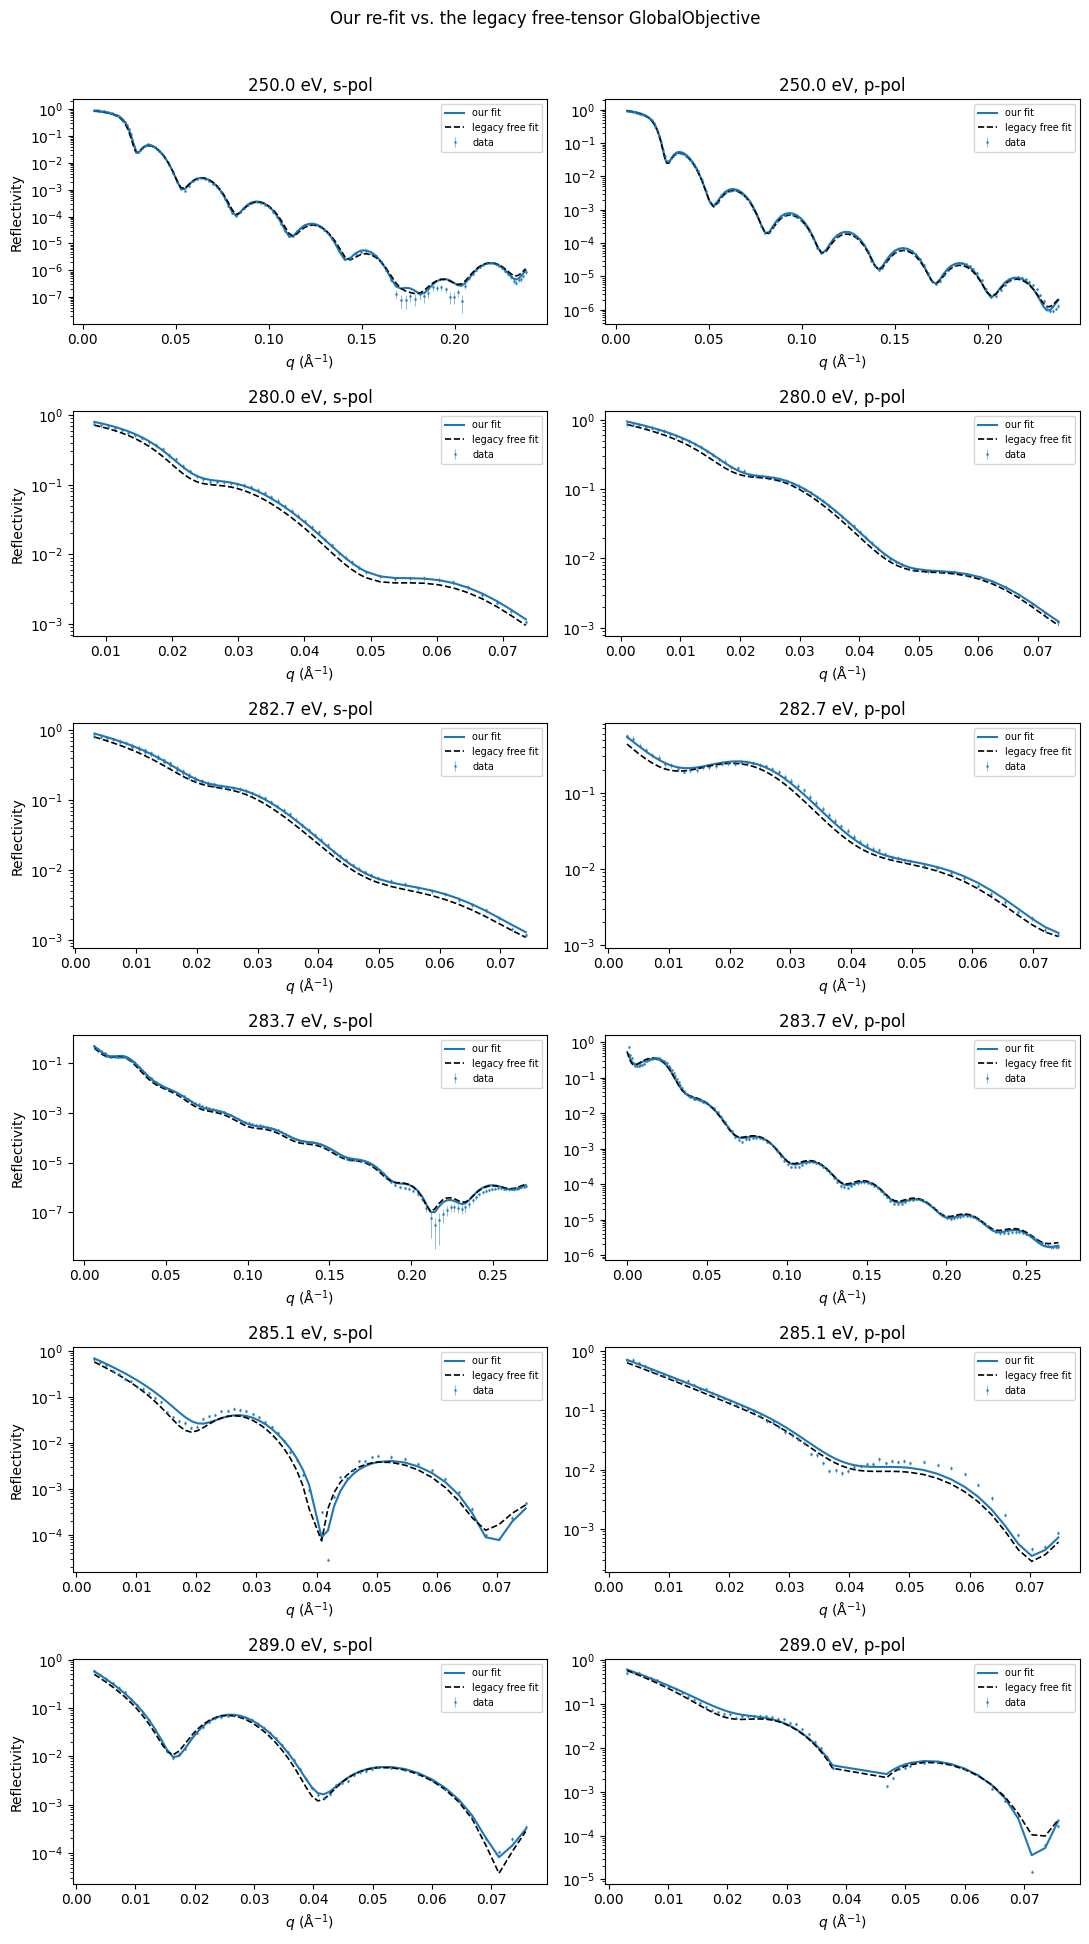

In [11]:
fig, axes = plt.subplots(len(show_energies), 2, figsize=(11, 3.2 * len(show_energies)))
for row, energy in enumerate(show_energies):
    legacy_group = free_frame.filter(pl.col("energy") == energy)
    for col, pol in enumerate(("s", "p")):
        ax = axes[row, col]
        for e, p, indices in dataset.groups():
            if e != energy or p != pol:
                continue
            q = dataset.q[indices]
            ax.errorbar(
                q,
                dataset.r[indices],
                yerr=dataset.r_err[indices],
                fmt=".",
                ms=2,
                lw=0.5,
                alpha=0.7,
                label="data",
            )
            result = model(q, energy)
            fit = result.s if pol == "s" else result.p
            ax.plot(q, fit, color="C0", lw=1.5, label="our fit")
        sub = legacy_group.filter(pl.col("pol") == pol)
        if not sub.is_empty():
            ax.plot(
                sub["q"].to_numpy(),
                sub["legacy_pred"].to_numpy(),
                color="k",
                ls="--",
                lw=1.2,
                label="legacy free fit",
            )
        ax.set_yscale("log")
        ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
        ax.set_title(f"{energy:.1f} eV, {pol}-pol")
        if col == 0:
            ax.set_ylabel("Reflectivity")
        ax.legend(fontsize="x-small")
fig.suptitle("Our re-fit vs. the legacy free-tensor GlobalObjective", y=1.01)
fig.tight_layout()
plt.show()


## Tensor trace overlay vs legacy free fit

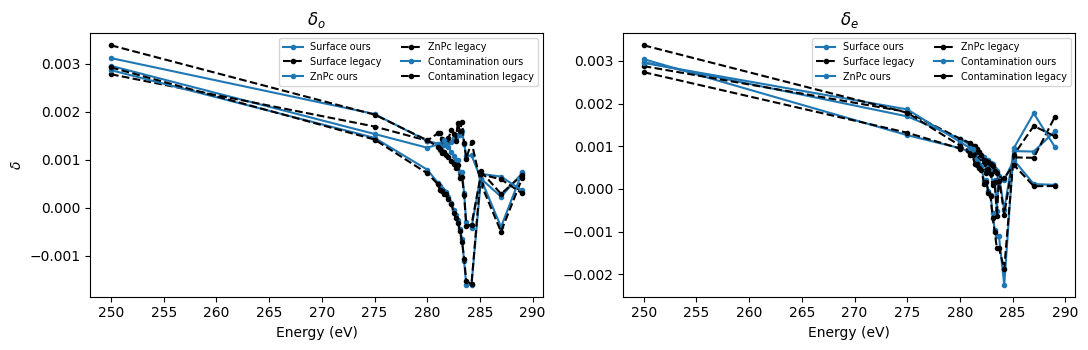

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for layer_name in FILM_LAYER_NAMES:
    sld = structure.slab(layer_name).sld
    assert isinstance(sld, FreeTensorSLD)
    legacy = free_layers[layer_name]
    es = sorted(float(e) for e in legacy["tensor_by_energy"])
    ours_do = [float(sld.channel_at(e).delta_o.value or 0.0) for e in es]
    ours_de = [float(sld.channel_at(e).delta_e.value or 0.0) for e in es]
    legacy_do = [legacy["tensor_by_energy"][str(e)]["delta_o"] for e in es]
    legacy_de = [legacy["tensor_by_energy"][str(e)]["delta_e"] for e in es]
    axes[0].plot(es, ours_do, color="C0", marker=".", label=f"{layer_name} ours")
    axes[0].plot(es, legacy_do, color="k", ls="--", marker=".", label=f"{layer_name} legacy")
    axes[1].plot(es, ours_de, color="C0", marker=".", label=f"{layer_name} ours")
    axes[1].plot(es, legacy_de, color="k", ls="--", marker=".", label=f"{layer_name} legacy")
axes[0].set_title(r"$\delta_o$")
axes[1].set_title(r"$\delta_e$")
for ax in axes:
    ax.set_xlabel("Energy (eV)")
    ax.legend(fontsize="x-small", ncol=2)
axes[0].set_ylabel(r"$\delta$")
fig.tight_layout()
plt.show()


## Model selection: refloxide refinement vs legacy free tensor

Same criteria as `real_data_fit.ipynb` / fig. 3. Both models use the **same** free set ($k=347$: geometry + instruments + film tensor channels), scored on this notebook's `dataset` with `Transform("logY")`.


In [13]:
def model_selection_stats(objective: Objective, *, use_logl: bool = False):
    """Reduced chi2, AIC, and BIC from an Objective (fig_3_orientation convention)."""
    resid = np.asarray(objective.residuals(), dtype=float)
    n = int(resid.size)
    k = len(objective.varying_parameters())
    chi2 = float(np.sum(resid**2))
    nu = max(n - k, 1)
    if use_logl:
        logl = float(objective.logl())
        aic = 2.0 * k - 2.0 * logl
        bic = k * np.log(n) - 2.0 * logl
    else:
        aic = chi2 + 2.0 * k
        bic = chi2 + k * np.log(n)
    return {
        "chi2": chi2 / nu,
        "aic": aic,
        "bic": bic,
        "N": k,
        "npoints": n,
        "chi2_raw": chi2,
        "logl": float(objective.logl()),
    }


def apply_matched_k_flags(model: ReflectModel) -> None:
    """Same free/fixed pattern as the refinement (k=347)."""
    for param in model.parameters.flattened():
        param.vary = False
    for layer_name in FILM_LAYER_NAMES:
        slab = model.structure.slab(layer_name)
        slab.thick.vary = True
        slab.rough.vary = True
        sld = slab.sld
        assert isinstance(sld, FreeTensorSLD)
        for channel in sld._channels.values():
            channel.delta_o.vary = True
            channel.beta_o.vary = True
            channel.delta_e.vary = True
            channel.beta_e.vary = True
    oxide_l = model.structure.slab("Oxide")
    oxide_l.thick.vary = True
    oxide_l.rough.vary = True
    oxide_l.sld.density.vary = True
    sub_l = model.structure.slab("Substrate")
    sub_l.rough.vary = True
    sub_l.sld.density.vary = True
    for e in energies:
        model.scale_s.at(e).vary = True
        model.scale_p.at(e).vary = True
        model.theta_offset_s.at(e).vary = True
        model.theta_offset_p.at(e).vary = True


def build_legacy_free_objective() -> Objective:
    """Rebuild the published free-tensor fit with matched-k flags on ``dataset``."""
    legacy_model = ReflectModel(build_structure(), energies=energies, parallel=False)
    energy_offsets = {c["energy_offset"] for c in free_summary["corrections"]}
    assert len(energy_offsets) == 1
    legacy_model.energy_offset.setp(value=energy_offsets.pop(), vary=False)

    for c in free_summary["corrections"]:
        e = c["energy"]
        legacy_model.scale_s.at(e).setp(value=float(c["scale_s"]), vary=False)
        legacy_model.scale_p.at(e).setp(value=float(c["scale_p"]), vary=False)
        legacy_model.theta_offset_s.at(e).setp(
            value=float(c["theta_offset_p"]), vary=False
        )
        legacy_model.theta_offset_p.at(e).setp(
            value=float(c["theta_offset_s"]), vary=False
        )
        legacy_model.bkg.at(e).setp(value=float(c["bkg"]), vary=False)

    apply_matched_k_flags(legacy_model)
    return Objective(
        legacy_model, dataset, transform=Transform("logY"), nc_constraint=False
    )


set_instrument_vary(True)
set_geometry_vary(True, final=True)
set_tensor_vary(True)
ours_objective = objective
assert len(ours_objective.varying_parameters()) == TARGET_K

legacy_objective = build_legacy_free_objective()
assert len(legacy_objective.varying_parameters()) == TARGET_K

STATS_USE_LOGL = True
stats = {
    "Legacy free tensor": model_selection_stats(
        legacy_objective, use_logl=STATS_USE_LOGL
    ),
    "Refloxide refit": model_selection_stats(ours_objective, use_logl=STATS_USE_LOGL),
}
stats_chi2 = {
    "Legacy free tensor": model_selection_stats(legacy_objective, use_logl=False),
    "Refloxide refit": model_selection_stats(ours_objective, use_logl=False),
}
stats_logl = {
    "Legacy free tensor": model_selection_stats(legacy_objective, use_logl=True),
    "Refloxide refit": model_selection_stats(ours_objective, use_logl=True),
}

print(
    f"{'model':<20}{'n':>8}{'k':>6}{'chi2_nu':>10}"
    f"{'AIC_chi2':>12}{'BIC_chi2':>12}{'AIC_logl':>12}{'BIC_logl':>12}"
)
print("-" * 94)
for name in stats:
    c, lg = stats_chi2[name], stats_logl[name]
    print(
        f"{name:<20}{c['npoints']:>8d}{c['N']:>6d}{c['chi2']:>10.3f}"
        f"{c['aic']:>12.1f}{c['bic']:>12.1f}{lg['aic']:>12.1f}{lg['bic']:>12.1f}"
    )

refit_wins_aic = stats["Refloxide refit"]["aic"] < stats["Legacy free tensor"]["aic"]
refit_wins_bic = stats["Refloxide refit"]["bic"] < stats["Legacy free tensor"]["bic"]
refit_wins_chi2 = stats["Refloxide refit"]["chi2"] < stats["Legacy free tensor"]["chi2"]
print(f"\nDrop-in replacement gate (lower is better, matched k={TARGET_K}):")
print(f"  reduced chi2_nu: refit {'WINS' if refit_wins_chi2 else 'LOSES'}")
print(f"  AIC:             refit {'WINS' if refit_wins_aic else 'LOSES'}")
print(f"  BIC:             refit {'WINS' if refit_wins_bic else 'LOSES'}")
if refit_wins_aic and refit_wins_bic:
    print("  => Refloxide refinement outperforms legacy free tensor on AIC and BIC.")
else:
    print("  => Keep legacy free tensor for fig_2 until the refinement wins AIC and BIC.")


model                      n     k   chi2_nu    AIC_chi2    BIC_chi2    AIC_logl    BIC_logl
----------------------------------------------------------------------------------------------
Legacy free tensor      2765   347     9.698     24144.6     26200.5     10821.3     12877.2
Refloxide refit         2765   347     2.969      7873.3      9929.2     -5450.0     -3394.1

Drop-in replacement gate (lower is better, matched k=347):
  reduced chi2_nu: refit WINS
  AIC:             refit WINS
  BIC:             refit WINS
  => Refloxide refinement outperforms legacy free tensor on AIC and BIC.


## Save fitted objective

In [ ]:
FIT_OUT_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/refloxide"
FIT_OUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_OUT_PATH = FIT_OUT_DIR / "free-refit-refloxide.pkl"

with FIT_OUT_PATH.open("wb") as f:
    pickle.dump(objective, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"saved fitted objective to {FIT_OUT_PATH}")
